In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_excel(r"C:\Users\mehemmed\Downloads\Pokemon.xlsx")

In [9]:
df.head(20)

,#,name,type1,type2,base_total,hp,attack,defense,sp_attack,sp_defense,speed,height_m,weight_kg,is_legendary,generation,capture_rate,base_happiness,percentage_male
0,1,Bulbasaur,grass,poison,318,45,49,49,65,65,45,0.7,6.9,0,1,45,70,88.1
1,2,Ivysaur,grass,poison,405,60,62,63,80,80,60,1.0,13.0,0,1,45,70,88.1
2,3,Venusaur,grass,poison,625,80,100,123,122,120,80,2.0,100.0,0,1,45,70,88.1
3,4,Charmander,fire,NaN,309,39,52,43,60,50,65,0.6,8.5,0,1,45,70,88.1
4,5,Charmeleon,fire,NaN,405,58,64,58,80,65,80,1.1,19.0,0,1,45,70,88.1
5,6,Charizard,fire,flying,634,78,104,78,159,115,100,1.7,90.5,0,1,45,70,88.1
6,7,Squirtle,water,NaN,314,44,48,65,50,64,43,0.5,9.0,0,1,45,70,88.1
7,8,Wartortle,water,NaN,405,59,63,80,65,80,58,1.0,22.5,0,1,45,70,88.1
8,9,Blastoise,water,NaN,630,79,103,120,135,115,78,1.6,85.5,0,1,45,70,88.1
9,10,Caterpie,bug,NaN,195,45,30,35,20,20,45,0.3,2.9,0,1,255,70,50.0


1. Datasetdə ən çox yayılmış Pokemon növü hansıdır? Bu tipdən neçə Pokemon var?

In [59]:
all_types = pd.concat([df["type1"], df["type2"]])
print(f"Ən çox yayılmış Pokemon növü: {all_types.value_counts().idxmax()}")
print(f"Sayı: {all_types.value_counts().max()}")

Ən çox yayılmış Pokemon növü: water
Sayı: 131


2.   Digər növlərlə müqayisədə həddindən artıq yüksək və ya aşağı statistikaya malik hər hansı Pokemon varmı?

In [61]:
Q1 = df['base_total'].quantile(0.25)
Q3 = df['base_total'].quantile(0.75)
IQR = Q3 - Q1
yuxari_serhed = Q3 + (1.5 * IQR)
asagi_serhed = Q1 - (1.5 * IQR)
anormal_pokemonlar = df[(df['base_total'] > yuxari_serhed) | (df['base_total'] < asagi_serhed)]
print(f"base_total üzrə yuxarı sərhəd: {yuxari_serhed}")
print(f"base_total üzrə aşağı sərhəd: {asagi_serhed}\n")
if anormal_pokemonlar.empty:
    print("base_total göstəricisinə görə həddindən artıq yüksək və ya aşağı statistikaya malik hər hansı Pokemon yoxdur")
else:
    print("base_total göstəricisinə görə Outlier olan Pokemonlar")
    print(anormal_pokemonlar[['name', 'base_total']].sort_values(by='base_total', ascending=False))

base_total üzrə yuxarı sərhəd: 782.5
base_total üzrə aşağı sərhəd: 42.5

base_total göstəricisinə görə həddindən artıq yüksək və ya aşağı statistikaya malik hər hansı Pokemon yoxdur


3. Pokemonun capture rate ilə onun base total göstəricisi arasında əlaqə varmı? Bəs onun nadirliyi (legendary olub-olmaması) ilə əlaqəsi necədir?

In [116]:
df['capture_rate'] = pd.to_numeric(df['capture_rate'], errors='coerce')
korelyasiya = df['capture_rate'].corr(df['base_total'])
print(f"Capture Rate və Base Total arasındakı korrelyasiya: {korelyasiya:.2f}")
print("(Nəticə -1-ə yaxın olduqda mənfi əlaqə daha güclüdür)\n")
muqayise = df.groupby('is_legendary')[['capture_rate', 'base_total']].mean()
muqayise.index = ['Adi Pokemon', 'Əfsanəvi Pokemon']
print("Nadirliyə görə ortalamalar:")
print(muqayise)

Capture Rate və Base Total arasındakı korrelyasiya: -0.71
(Nəticə -1-ə yaxın olduqda mənfi əlaqə daha güclüdür)

Nadirliyə görə ortalamalar:
                  capture_rate  base_total
Adi Pokemon         106.506849  410.358904
Əfsanəvi Pokemon     17.985714  615.257143


4. Hansı Pokemon ən yüksək Attack (Hücum) statistikasına malikdir?

In [84]:
en_hucumcu = df.loc[df['attack'].idxmax()]
print(f"Ən yüksək fiziki hücuma malik Pokemon: {en_hucumcu['name']} ({en_hucumcu['attack']})")
en_xususi_hucumcu = df.loc[df['sp_attack'].idxmax()]
print(f"Ən yüksək xüsusi hücuma malik Pokemon: {en_xususi_hucumcu['name']} ({en_xususi_hucumcu['sp_attack']})")

Ən yüksək fiziki hücuma malik Pokemon: Heracross (185)
Ən yüksək xüsusi hücuma malik Pokemon: Mewtwo (194)


5. Base Total ilə HP, Attack, Defense, Special Attack, Special Defense və Speed atributlarının hər biri arasında korrelyasiya nədir?

In [73]:
statistika = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']
korelyasiyalar = df[statistika].corrwith(df['base_total'])
print("Base Total ilə digər statistikaların korrelyasiyası:")
print(korelyasiyalar.sort_values(ascending=False))

Base Total ilə digər statistikaların korrelyasiyası:
sp_attack     0.740986
attack        0.729998
sp_defense    0.717958
defense       0.630151
hp            0.621062
speed         0.547575
dtype: float64


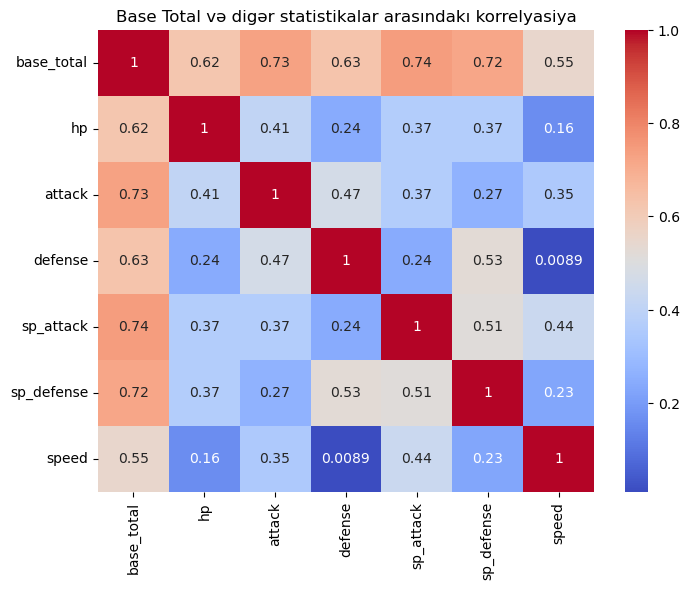

In [76]:
statistika = ['base_total','hp','attack','defense',
              'sp_attack','sp_defense','speed']
corr_matrix = df[statistika].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Base Total və digər statistikalar arasındakı korrelyasiya")
plt.show()

6. Əfsanəvi (Legendary) və əfsanəvi olmayan Pokemonların orta hücum göstəriciləri arasında əhəmiyyətli fərq varmı?

In [114]:
ortalamalar = (
    df.groupby('is_legendary')[['weight_kg', 'height_m']]
      .mean()
      .reset_index()
)
ortalamalar

,is_legendary,weight_kg,height_m
0,0,48.018425,1.056681
1,1,199.350725,2.281159


7. Hansı tip 1 və tip 2 kombinasiyaları Pokemonlar arasında ən çox yayılmışdır?

In [85]:
top_tipler = df[['type1', 'type2']].value_counts().reset_index(name='say')
print("Ən çox yayılmış 10 Pokémon tip kombinasiyası:\n")
print(top_tipler.head(10).to_string(index=False))

Ən çox yayılmış 10 Pokémon tip kombinasiyası:

 type1    type2  say
normal   flying   26
 grass   poison   14
   bug   flying   13
   bug   poison   11
 water   ground    9
 water   flying    7
  rock    water    6
 grass   flying    6
  rock   ground    6
  fire fighting    6


8. Pokemonun çəkisi (Weight) və boyu (Height) arasında korrelyasiya varmı?

In [87]:
korelyasiya = df['height_m'].corr(df['weight_kg'])
print(f"Boy və çəki arasındakı korrelyasiya əmsalı: {korelyasiya:.2f}")
print("(Nəticə 1-ə yaxın olduqda müsbət əlaqə daha güclü olur)")

Boy və çəki arasındakı korrelyasiya əmsalı: 0.63
(Nəticə 1-ə yaxın olduqda müsbət əlaqə daha güclü olur)


9. Hansı nəsil (Generation) ən yüksək orta sürətə (Speed) malikdir?

In [89]:
nesil_suret = df.groupby('generation')['speed'].mean().sort_values(ascending=False)
print("Nəsillərə görə orta sürət göstəriciləri:")
print(nesil_suret.round(2))
en_suretli_nesil = nesil_suret.idxmax()
print(f"\nƏn yüksək orta sürətə malik nəsil: Generation {en_suretli_nesil}")
print(f"Orta sürət göstəricisi: {nesil_suret.max():.2f}")

Nəsillərə görə orta sürət göstəriciləri:
generation
1    70.15
4    70.07
6    66.65
5    66.52
3    63.58
7    63.33
2    61.61
Name: speed, dtype: float64

Ən yüksək orta sürətə malik nəsil: Generation 1
Orta sürət göstəricisi: 70.15


10. Base Total paylanması əfsanəvi və əfsanəvi olmayan Pokemonlar arasında necə dəyişir?

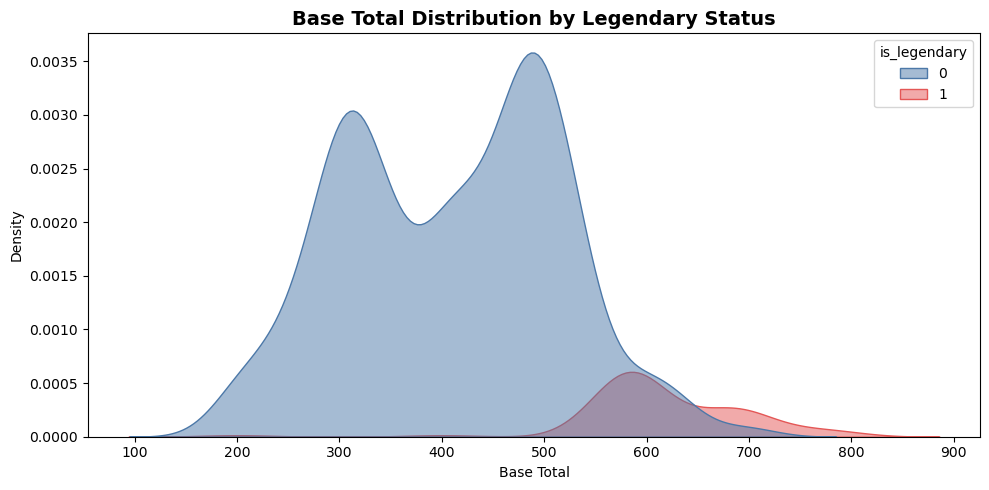

In [90]:
plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=df,
    x='base_total',
    hue='is_legendary',
    fill=True,
    alpha=0.5,
    palette=['#4C78A8', '#E45756']
)
plt.title(
    'Base Total Distribution by Legendary Status',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Base Total')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

11. Müxtəlif Pokemon tipləri arasında Defense göstəricisinin paylanmasında əhəmiyyətli fərq varmı?

C:\Users\mehemmed\AppData\Local\Temp\ipykernel_41980\3629343018.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


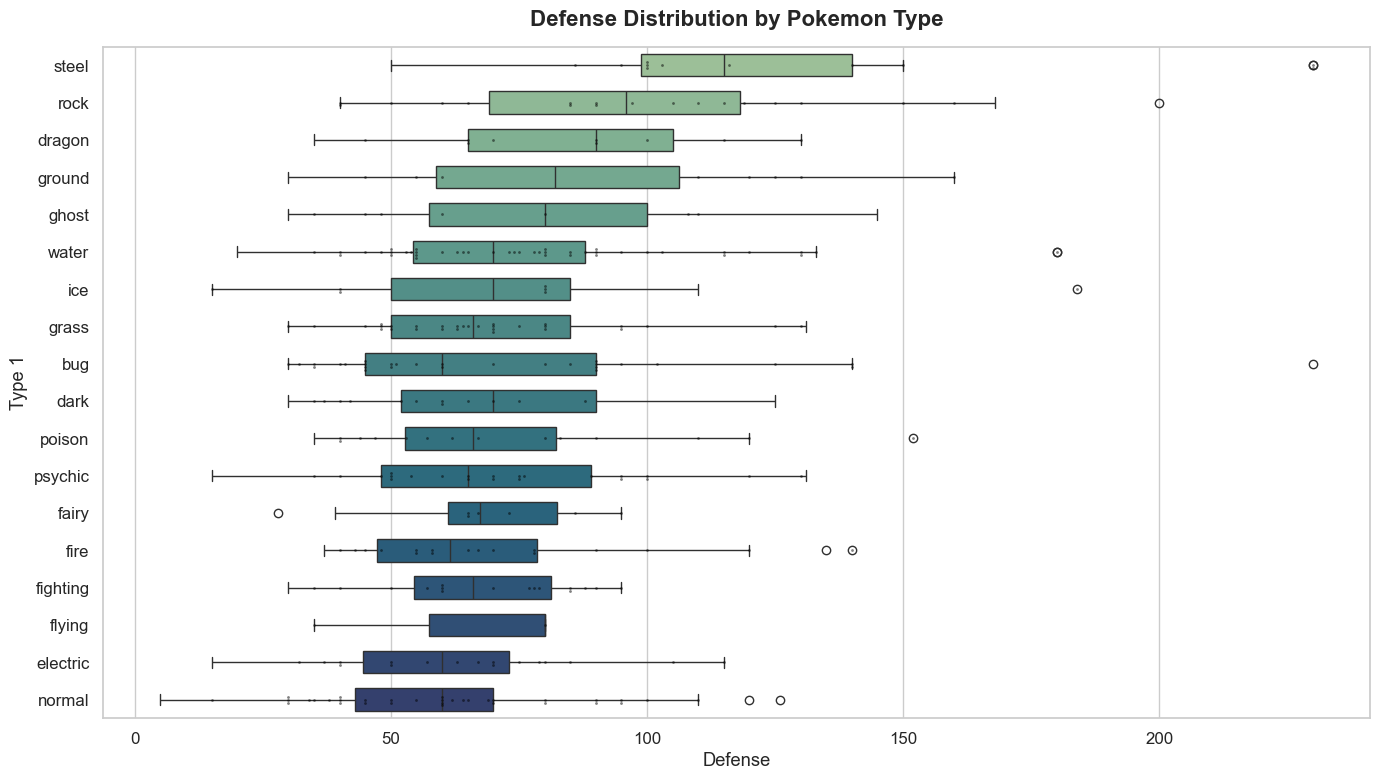

In [92]:
plt.figure(figsize=(14, 8))
type1_order = (
    df.groupby('type1')['defense']
      .mean()
      .sort_values(ascending=False)
      .index
)
sns.set_theme(style="whitegrid", font_scale=1.1)
sns.boxplot(
    data=df,
    y='type1',
    x='defense',
    order=type1_order,
    palette='crest',
    width=0.6
)
sns.swarmplot(
    data=df.sample(min(300, len(df))),
    y='type1',
    x='defense',
    order=type1_order,
    color='black',
    size=2,
    alpha=0.5
)
plt.title(
    'Defense Distribution by Pokemon Type',
    fontsize=16,
    fontweight='bold',
    pad=15
)
plt.xlabel('Defense')
plt.ylabel('Type 1')
plt.tight_layout()
plt.show()

12. Pokemonun adını input kimi qəbul edən və onun statistikalarının olduğu lüğəti (dictionary) qaytaran funksiya yazın.

In [93]:
def pokemon_statistikasi(ad):
    netice = df[
        df['name'].str.lower() == ad.strip().lower()
    ].to_dict('records')
    if netice:
        return netice[0]
    return {"Xəta": f"'{ad}' adlı Pokémon tapılmadı."}
statistika = pokemon_statistikasi("Pikachu")
for acar, deyer in statistika.items():
    print(f"{acar}: {deyer}")

#: 25
name: Pikachu
type1: electric
type2: nan
base_total: 320
hp: 35
attack: 55
defense: 40
sp_attack: 50
sp_defense: 50
speed: 90
height_m: 0.4
weight_kg: 6.0
is_legendary: 0
generation: 1
capture_rate: 190
base_happiness: 70
percentage_male: 50.0


13. percentage_male sütununda olan boş dəyərləri həmin Pokemon tipinin orta göstəricisi ilə doldurun.

In [94]:
df['percentage_male'] = df['percentage_male'].fillna(
    df.groupby('type1')['percentage_male'].transform('mean')
)
print(df['percentage_male'])

0      88.100000
1      88.100000
2      88.100000
3      88.100000
4      88.100000
         ...    
795    50.000000
796    58.978378
797    50.550000
798    51.058333
799    50.000000
Name: percentage_male, Length: 800, dtype: float64


14. Daha çox kişiyə yaxın olan Pokemonlar daha güclüdür, yoxsa qadına yaxın olanlar?

In [96]:
kisi_yaxin_ort = df[df['percentage_male'] > 50]['base_total'].mean()
qadin_yaxin_ort = df[df['percentage_male'] < 50]['base_total'].mean()
print(f"Kişiyə yaxın Pokemonların orta Base Total göstəricisi: {kisi_yaxin_ort:.2f}")
print(f"Qadına yaxın Pokemonların orta Base Total göstəricisi: {qadin_yaxin_ort:.2f}")
if kisi_yaxin_ort > qadin_yaxin_ort:
    ferq = kisi_yaxin_ort - qadin_yaxin_ort
    print(f"\nNəticə: Kişiyə yaxın Pokemonlar orta hesabla {ferq:.2f} xal daha güclüdür.")
elif qadin_yaxin_ort > kisi_yaxin_ort:
    ferq = qadin_yaxin_ort - kisi_yaxin_ort
    print(f"\nNəticə: Qadına yaxın Pokemonlar orta hesabla {ferq:.2f} xal daha güclüdür.")
else:
    print("\nNəticə: Hər iki qrupun orta gücü eynidir.")

Kişiyə yaxın Pokemonların orta Base Total göstəricisi: 470.66
Qadına yaxın Pokemonların orta Base Total göstəricisi: 437.41

Nəticə: Kişiyə yaxın Pokemonlar orta hesabla 33.24 xal daha güclüdür.


15. Əfsanəvi və əfsanəvi olmayan Pokemonların orta çəkiləri və boyları arasında əhəmiyyətli fərq varmı?

C:\Users\mehemmed\AppData\Local\Temp\ipykernel_41980\3584231209.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\mehemmed\AppData\Local\Temp\ipykernel_41980\3584231209.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


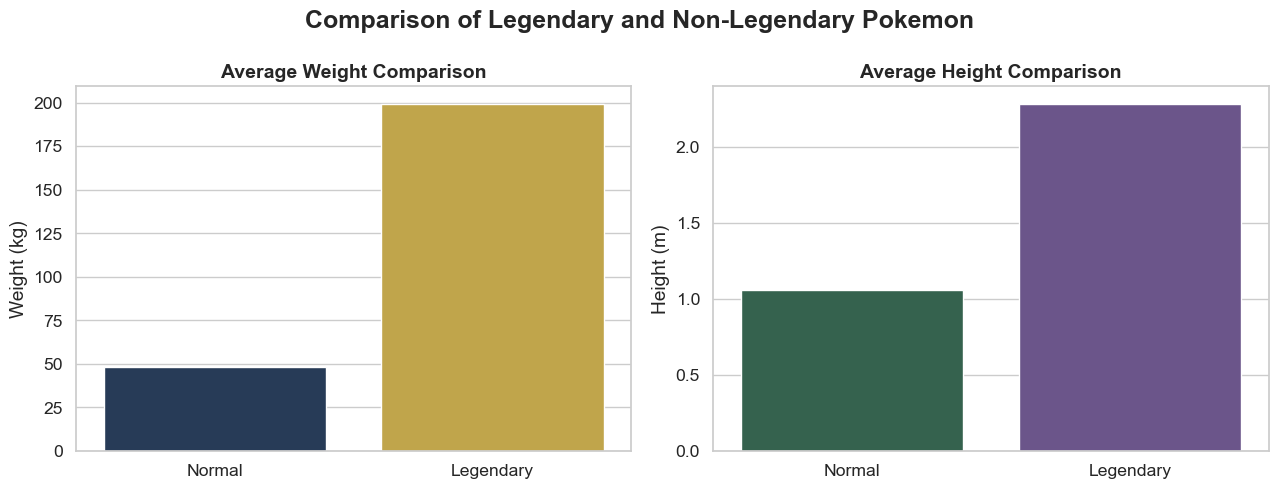

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", font_scale=1.15)
ortalamalar = df.groupby('is_legendary')[['weight_kg', 'height_m']].mean()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(
    x=['Normal', 'Legendary'],
    y=ortalamalar['weight_kg'].values,
    palette=['#1F3A5F', '#D4AF37'],
    ax=axes[0]
)
axes[0].set_title(
    'Average Weight Comparison',
    fontsize=14,
    fontweight='bold'
)
axes[0].set_ylabel('Weight (kg)')
axes[0].set_xlabel('')
sns.barplot(
    x=['Normal', 'Legendary'],
    y=ortalamalar['height_m'].values,
    palette=['#2D6A4F', '#6A4C93'],
    ax=axes[1]
)
axes[1].set_title(
    'Average Height Comparison',
    fontsize=14,
    fontweight='bold'
)
axes[1].set_ylabel('Height (m)')
axes[1].set_xlabel('')
plt.suptitle(
    'Comparison of Legendary and Non-Legendary Pokemon',
    fontsize=18,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

16. Hansı Type1 və Type2 kombinasiyası daha xoşbəxtdir (base_happiness göstəricisinə görə)?

In [106]:
en_xosbext_tipler = (
    df.groupby(['type1', 'type2'])['base_happiness']
      .mean()
      .reset_index()
      .sort_values(by='base_happiness', ascending=False)
      .round(2)
)
print("Base Happiness göstəricisinə görə ən xoşbəxt 10 Type1-Type2 kombinasiyası:\n")
print(en_xosbext_tipler.head(10).to_string(index=False))
en_xosbext = en_xosbext_tipler.iloc[0]
print(
    f"\nƏn xoşbəxt kombinasiya: "
    f"{en_xosbext['type1']} - {en_xosbext['type2']}"
)
print(
    f"Orta Base Happiness göstəricisi: "
    f"{en_xosbext['base_happiness']:.2f}"
)

Base Happiness göstəricisinə görə ən xoşbəxt 10 Type1-Type2 kombinasiyası:

  type1    type2  base_happiness
  grass    grass          100.00
   fire    steel          100.00
   fire    water          100.00
psychic    grass          100.00
psychic     fire          100.00
 dragon  psychic           90.00
 poison fighting           85.00
 normal  psychic           80.00
 ground   flying           76.67
    ice   ground           70.00

Ən xoşbəxt kombinasiya: grass - grass
Orta Base Happiness göstəricisi: 100.00


17. Tiplər üzrə orta çəki və boy göstəricilərini hesablayın.

In [108]:
t1 = df[['type1', 'weight_kg', 'height_m']].rename(columns={'type1': 'tip'})
t2 = df[['type2', 'weight_kg', 'height_m']].rename(columns={'type2': 'tip'})
birlesmis_df = pd.concat([t1, t2])
umumi_tipler_ort = (
    birlesmis_df
    .groupby('tip')[['weight_kg', 'height_m']]
    .mean()
    .round(2)
    .reset_index()
    .sort_values(by='weight_kg', ascending=False)
)
print("Pokemon tipləri üzrə orta çəki və boy göstəriciləri:\n")
print(umumi_tipler_ort.to_string(index=False))

Pokemon tipləri üzrə orta çəki və boy göstəriciləri:

     tip  weight_kg  height_m
  dragon     156.67      2.11
   steel     147.14      1.51
  ground     126.18      1.58
     ice     113.26      1.39
    rock      97.12      1.27
fighting      71.31      1.30
    dark      68.34      1.29
   ghost      68.09      1.32
 psychic      65.34      1.08
    fire      63.38      1.16
   water      51.14      1.24
  flying      50.98      1.35
  normal      45.56      1.02
electric      41.37      0.99
   grass      33.69      0.96
     bug      33.26      0.89
  poison      29.78      1.07
   fairy      19.30      0.76


18. Siz oynamaq üçün ən ideal Pokemonu seçmək istəsəniz, hansını seçərdiniz? Bunun

In [110]:
ideal_pokemon = df.sort_values(
    by=["base_total", "attack", "speed"],
    ascending=False
)
print(ideal_pokemon[
    ["name", "base_total", "attack", "speed"]
].head(10))

          name  base_total  attack  speed
383   Rayquaza         780     180    115
149     Mewtwo         780     150    140
382    Groudon         770     180     90
381     Kyogre         770     150     90
492     Arceus         720     120    120
717    Zygarde         708     100     85
444   Garchomp         700     170     92
247  Tyranitar         700     164     71
718    Diancie         700     160    110
372  Salamence         700     145    120


19.Apardığınız analizlərin nəticələrinə uyğun vizuallaşdırmalar hazırlayın və sadə bir dashboard qurun.

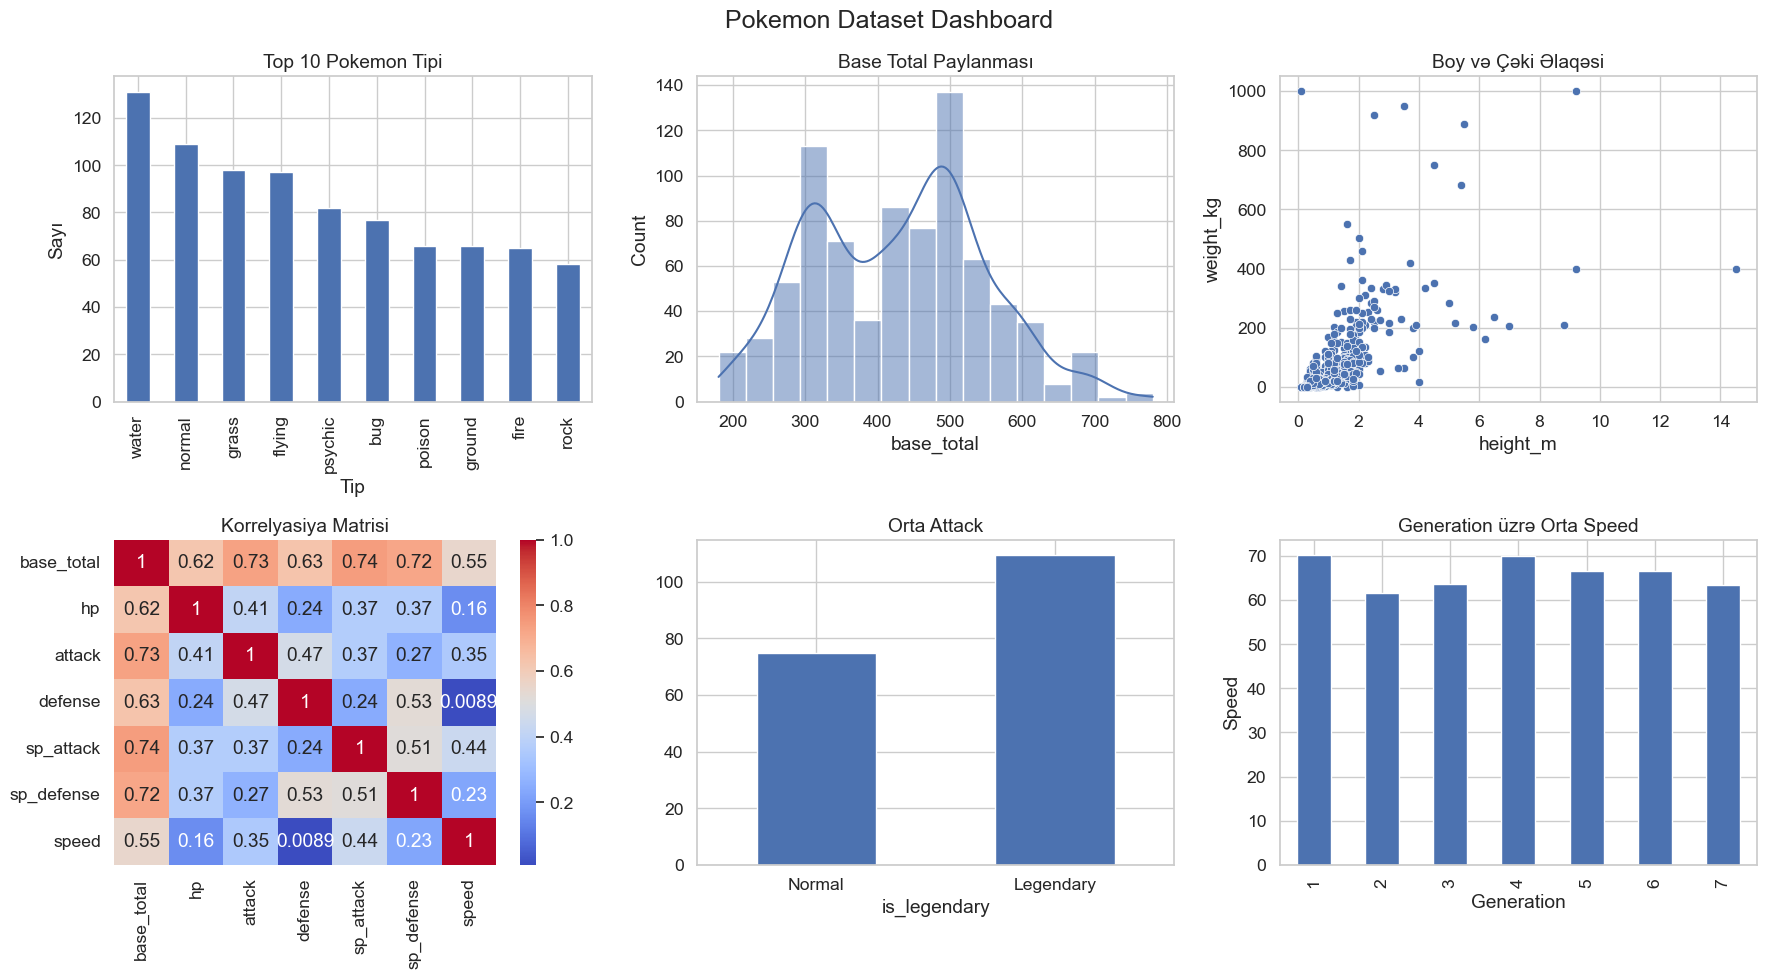

In [112]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
all_types = pd.concat([df["type1"], df["type2"]]).dropna()
all_types.value_counts().head(10).plot(
    kind="bar",
    ax=axes[0,0]
)
axes[0,0].set_title("Top 10 Pokemon Tipi")
axes[0,0].set_xlabel("Tip")
axes[0,0].set_ylabel("Sayı")
sns.histplot(
    data=df,
    x="base_total",
    kde=True,
    ax=axes[0,1]
)
axes[0,1].set_title("Base Total Paylanması")
sns.scatterplot(
    data=df,
    x="height_m",
    y="weight_kg",
    ax=axes[0,2]
)
axes[0,2].set_title("Boy və Çəki Əlaqəsi")
statistika = [
    "base_total",
    "hp",
    "attack",
    "defense",
    "sp_attack",
    "sp_defense",
    "speed"
]

sns.heatmap(
    df[statistika].corr(),
    annot=True,
    cmap="coolwarm",
    ax=axes[1,0]
)

axes[1,0].set_title("Korrelyasiya Matrisi")
ortalama_attack = df.groupby("is_legendary")["attack"].mean()
ortalama_attack.plot(
    kind="bar",
    ax=axes[1,1]
)
axes[1,1].set_title("Orta Attack")
axes[1,1].set_xticklabels(
    ["Normal", "Legendary"],
    rotation=0
)
df.groupby("generation")["speed"].mean().plot(
    kind="bar",
    ax=axes[1,2]
)
axes[1,2].set_title("Generation üzrə Orta Speed")
axes[1,2].set_xlabel("Generation")
axes[1,2].set_ylabel("Speed")
plt.suptitle(
    "Pokemon Dataset Dashboard",
    fontsize=18
)
plt.tight_layout()
plt.show()

In [113]:
print("""
╔════════════════════════════════════╗
║      POKEMON ANALYTICS DASHBOARD   ║
╚════════════════════════════════════╝

               ／＞　 フ
              | 　_　_ |
            ／` ミ＿xノ
           /　　　　 |
          /　 ヽ　　 ﾉ
         │　　|　|　|
    ／￣|　　 |　|　|
   (￣ヽ＿_ヽ_)__)
    ＼二)

        Eevee 🦊✨

Dashboard uğurla tamamlandı!
""")


╔════════════════════════════════════╗
║      POKEMON ANALYTICS DASHBOARD   ║
╚════════════════════════════════════╝

               ／＞　 フ
              | 　_　_ |
            ／` ミ＿xノ
           /　　　　 |
          /　 ヽ　　 ﾉ
         │　　|　|　|
    ／￣|　　 |　|　|
   (￣ヽ＿_ヽ_)__)
    ＼二)

        Eevee 🦊✨

Dashboard uğurla tamamlandı!

